In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

In [54]:
df = pd.read_csv("/content/drive/MyDrive/REsnet/IMDB Dataset.csv")

In [56]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

In [58]:
max_words = 10000
max_len = 200

In [59]:
tokenizer = Tokenizer(num_words=max_words, lower=True, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)


In [60]:
model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_4          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [61]:
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=4,
    batch_size=128
)

Epoch 1/4
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.6498 - loss: 0.5969 - val_accuracy: 0.8710 - val_loss: 0.2984
Epoch 2/4
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9074 - loss: 0.2423 - val_accuracy: 0.8949 - val_loss: 0.2540
Epoch 3/4
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9638 - loss: 0.1168 - val_accuracy: 0.8891 - val_loss: 0.2914
Epoch 4/4
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9910 - loss: 0.0430 - val_accuracy: 0.8955 - val_loss: 0.3263


In [62]:
loss, acc = model.evaluate(X_test_pad, y_test)
print(f"\nTest Accuracy: {acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8877 - loss: 0.3349

Test Accuracy: 0.8908


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


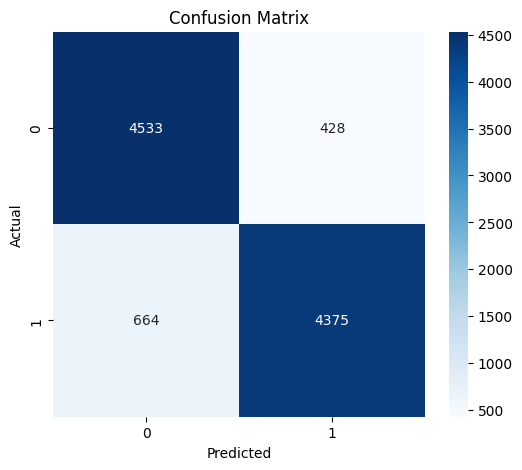

In [63]:
y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [67]:
def predict_sentiment(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len)
    prob = model.predict(pad)[0][0]
    label = "POSITIVE" if prob >= 0.5 else "NEGATIVE"
    print(f"{text}\nPrediction: {label}" )

In [68]:
predict_sentiment("This movie was fantastic and I loved it!")
predict_sentiment("This was the worst movie I have ever seen.")
predict_sentiment("The acting was okay but the story was boring.")
predict_sentiment("Worst acting ever")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
This movie was fantastic and I loved it!
Prediction: POSITIVE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
This was the worst movie I have ever seen.
Prediction: NEGATIVE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
The acting was okay but the story was boring.
Prediction: NEGATIVE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Worst acting ever
Prediction: NEGATIVE
